# Ch 14 · Lab 4 — EarlyStopping

원본: `11_Wine_Early_Stop.py`

val_loss 가 100 에포크 동안 개선되지 않으면 자동 중단.

## 0. 환경

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import Input, Sequential
from keras.layers import Dense

keras.utils.set_random_seed(0)

print("Keras:", keras.__version__)

from keras.callbacks import ModelCheckpoint, EarlyStopping

2026-05-12 17:27:43.098119: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778574463.120682 1693926 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778574463.127300 1693926 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras: 3.14.1


## 1. 데이터 (15% 샘플 — Lab 3과 동일 조건)

In [2]:
DATA = "../../data/wine.csv"
df_full = pd.read_csv(DATA, header=None)
df = df_full.sample(frac=0.15, random_state=0).reset_index(drop=True)  # 일부러 작게
X = df.iloc[:, 0:12].to_numpy(dtype="float32")
y = df.iloc[:, 12].to_numpy(dtype="float32")
print("샘플링 후 X:", X.shape)

샘플링 후 X: (975, 12)


## 2. 모델 + EarlyStopping

In [3]:
def build_model():
    return Sequential([
        Input(shape=(12,)),
        Dense(30, activation="relu"),
        Dense(12, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])

keras.utils.set_random_seed(0)
model = build_model()
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

early_stopping = EarlyStopping(monitor="val_loss", patience=100, verbose=1)

2026-05-12 17:27:45.523976: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 3. 학습 (epochs=2000, 자동 중단)

In [4]:
hist = model.fit(X, y, validation_split=0.2, epochs=2000, batch_size=500,
                 verbose=0, callbacks=[early_stopping])

n_actual = len(hist.history["loss"])
print(f"\n실제 학습 에포크: {n_actual} / 2000  (EarlyStopping 발동)")
print(f"최종 train acc: {hist.history['accuracy'][-1]:.4f}")
print(f"전체 데이터 acc: {model.evaluate(X, y, verbose=0)[1]:.4f}")

Epoch 920: early stopping

실제 학습 에포크: 920 / 2000  (EarlyStopping 발동)
최종 train acc: 0.9936
전체 데이터 acc: 0.9938


## 4. 학습 곡선

/home/ubuntu/miniconda3/envs/modus-dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/miniconda3/envs/modus-dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/miniconda3/envs/modus-dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/miniconda3/envs/modus-dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/miniconda3/envs/modus-dl/lib/python3.11/site-packages/IPython/core/pylabtools.py:1

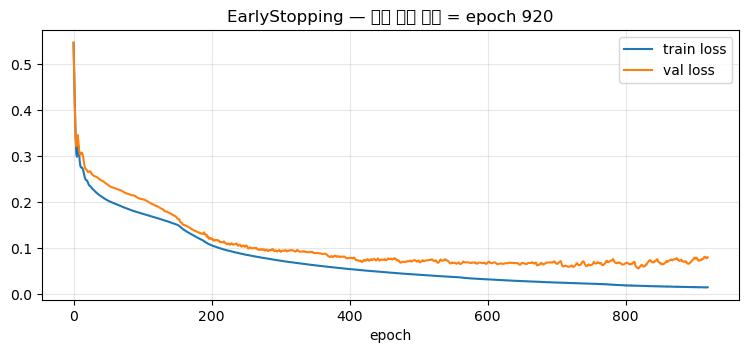

In [5]:
plt.figure(figsize=(9, 3.5))
plt.plot(hist.history["loss"],     label="train loss")
plt.plot(hist.history["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.legend(); plt.grid(alpha=0.3)
plt.title(f"EarlyStopping — 자동 중단 시점 = epoch {n_actual}")
plt.show()